<a href="https://colab.research.google.com/github/hmd264/data-science-2026/blob/main/Pertemuan_6_Ahmad%20Rilmansyah_240401010309.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pertemuan 6 — Persiapan Data**

Mata Kuliah: Pengantar Data Science (Kode: 200302305)

Program Studi: PJJ Informatika

Semester: 4

Dosen: Syahid Abdullah, S.Si, M.Kom

Nama : Ahmad Rilmansyah

NIM : 240401010309

## **Tujuan Notebook**

Notebook ini dibuat sebagai aktivitas hands-on Pertemuan 6 untuk:

    Memahami mengapa data mentah tidak bisa langsung dimasukkan ke model Machine Learning
    Menerapkan Label Encoding, One-Hot Encoding, dan Ordinal Encoding menggunakan Pandas & scikit-learn
    Menerapkan MinMaxScaler, StandardScaler, dan RobustScaler dan memahami perbedaannya
    Membagi dataset menjadi training set dan test set dengan train_test_split() + parameter stratify
    Membangun pipeline preprocessing end-to-end dataset Titanic tanpa menyebabkan data leakage

**Setup: Import Library**

In [ ]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn preprocessing
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
)
from sklearn.model_selection import train_test_split

# Pengaturan tampilan
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid', palette='Set2')
np.random.seed(42)

print('Semua library berhasil di-import.')
print(f'numpy   : {np.__version__}')
print(f'pandas  : {pd.__version__}')

## **BAGIAN 1 — Encoding Data Kategorikal**

Algoritma Machine Learning hanya bisa memproses angka. Nilai bertipe string seperti 'male', 'female', atau 'Jakarta' harus dikonversi menjadi representasi numerik. Tiga metode utama yang akan dipraktikkan: Label Encoding, One-Hot Encoding, dan Ordinal Encoding.
## **1.1 Label Encoding**

Konsep: Setiap kategori unik diberi satu bilangan bulat (0, 1, 2, ...) berdasarkan urutan alfabet (default).

Gunakan untuk:

    Kolom target (y) biner atau multi-kelas
    Atribut biner (Ya/Tidak, Lulus/Gagal)
    Fitur ordinal

## HINDARI untuk fitur nominal pada input X karena model akan mengasumsikan ada urutan (0 < 1 < 2) padahal tidak ada.


In [ ]:
# Contoh: kolom Gender (biner) - cocok untuk Label Encoding
df_le = pd.DataFrame({
    'Gender':   ['male', 'female', 'female', 'male', 'female'],
    'Survived': [0, 1, 1, 0, 1]
})

le = LabelEncoder()
df_le['Gender_enc'] = le.fit_transform(df_le['Gender'])

print('Hasil Label Encoding:')
print(df_le)

# Lihat pemetaan kelas
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f'\nPemetaan kelas: {mapping}')

# Decode balik ke label asli
decoded = le.inverse_transform([0, 1, 0])
print(f'Inverse transform [0,1,0]: {decoded}')

# **1.2 One-Hot Encoding (OHE)**

Konsep: Membuat satu kolom biner (0/1) untuk setiap nilai unik. Cara ini menghindari asumsi urutan yang menjadi masalah Label Encoding pada data nominal.

Gunakan untuk: semua fitur nominal pada input X (warna, kota, merek).

In [ ]:
# Contoh: kolom City (nominal) - cocok untuk One-Hot Encoding
df_city = pd.DataFrame({
    'City': ['Jakarta', 'Surabaya', 'Bandung', 'Jakarta', 'Surabaya']
})

# Cara 1: pd.get_dummies (paling mudah)
df_ohe = pd.get_dummies(df_city, columns=['City'],
                        drop_first=False, dtype=int)
print('Hasil One-Hot Encoding (drop_first=False):')
print(df_ohe)

In [ ]:
# Cara 2: pd.get_dummies dengan drop_first=True
# Untuk menghindari Dummy Variable Trap (multi-kolinearitas)
df_ohe_drop = pd.get_dummies(df_city, columns=['City'],
                             drop_first=True, dtype=int)
print('Hasil One-Hot Encoding (drop_first=True):')
print(df_ohe_drop)
print('\nCatatan: kolom City_Bandung dihapus. Jika City_Jakarta=0 dan City_Surabaya=0,')
print('maka bisa disimpulkan bahwa baris tersebut adalah Bandung.')

In [ ]:
# Cara 3: sklearn OneHotEncoder (untuk pipeline ML)
enc = OneHotEncoder(sparse_output=False, drop='first')
X_enc = enc.fit_transform(df_city[['City']])

print('Nama fitur hasil OHE :', enc.get_feature_names_out())
print('Matrix hasil OHE     :')
print(X_enc)

# **1.3 Ordinal Encoding**

Konsep: Mirip Label Encoding, tapi urutan dapat didefinisikan secara eksplisit sesuai makna domain — bukan hanya alfabet.

Gunakan untuk: fitur ordinal yang memiliki urutan alami, seperti tingkat pendidikan (SD < SMP < SMA < D3 < S1 < S2) atau ukuran baju (S < M < L < XL).

In [ ]:
# Contoh: Tingkat Pendidikan
df_edu = pd.DataFrame({
    'Pendidikan': ['SMA', 'S1', 'SD', 'D3', 'S2', 'SMP'],
    'Gaji_juta':  [5,    12,   3,    8,    18,   4]
})

# Definisikan urutan secara eksplisit (dari rendah ke tinggi)
edu_order = [['SD', 'SMP', 'SMA', 'D3', 'S1', 'S2']]

enc = OrdinalEncoder(
    categories=edu_order,
    handle_unknown='use_encoded_value',
    unknown_value=-1   # kategori baru di luar urutan diberi -1
)
df_edu['Pendidikan_enc'] = enc.fit_transform(df_edu[['Pendidikan']]).astype(int)

print('Hasil Ordinal Encoding (urutan sesuai jenjang pendidikan):')
print(df_edu.sort_values('Pendidikan_enc').reset_index(drop=True))
print('\nSD=0, SMP=1, SMA=2, D3=3, S1=4, S2=5')

**Ringkasan Perbandingan Metode Encoding**
Metode 	Jenis Data 	Gunakan untuk 	Hindari untuk
Label Encoding 	Biner / Ordinal 	Kolom target (y), atribut biner 	Fitur nominal pada input X
One-Hot Encoding 	Nominal 	Fitur nominal (warna, kota, merek) 	Kolom dengan >50 kategori unik
Ordinal Encoding 	Ordinal 	Fitur ordinal (pendidikan, ukuran) dgn urutan jelas 	Data nominal tanpa urutan alami

# **BAGIAN 2 — Scaling & Normalisasi Fitur**

Banyak algoritma ML (KNN, SVM, Linear/Logistic Regression, PCA, Neural Network) sensitif terhadap perbedaan skala antar fitur. Misalnya usia (0–100) vs pendapatan (0–50 juta) — fitur berskala besar akan mendominasi perhitungan jarak.

Kita akan bandingkan tiga scaler pada dataset kecil yang sama.

In [ ]:
# Dataset contoh: dua fitur dengan skala sangat berbeda
df_skala = pd.DataFrame({
    'Usia':       [25, 45, 32, 55, 28],
    'Pendapatan': [5,  20, 8,  35, 12]   # dalam juta rupiah
})

print('Data asli (skala sangat berbeda):')
print(df_skala)
print(f'\nStatistik:')
print(df_skala.describe().round(2))

# **2.1 MinMaxScaler — Normalisasi ke rentang [0, 1]**


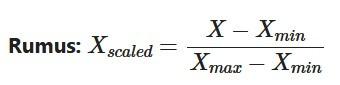

Hasil: nilai minimum asli → 0, nilai maksimum asli → 1.

In [ ]:
# MinMaxScaler
mm = MinMaxScaler(feature_range=(0, 1))
X_mm = mm.fit_transform(df_skala)

print(f'Min per fitur : {mm.data_min_}')
print(f'Max per fitur : {mm.data_max_}')
print('\nHasil MinMaxScaler (semua nilai di [0, 1]):')
print(pd.DataFrame(X_mm, columns=['Usia_mm', 'Pend_mm']).round(3))

# **2.2 StandardScaler — Z-score Standardization**

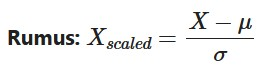



Hasil: mean = 0, standar deviasi = 1. Rentang tidak dibatasi [0,1], bisa negatif.

In [ ]:
# StandardScaler
ss = StandardScaler()
X_ss = ss.fit_transform(df_skala)

print(f'Mean per fitur  : {ss.mean_.round(3)}')
print(f'Scale per fitur : {ss.scale_.round(3)}')
print('\nHasil StandardScaler (mean=0, std=1):')
print(pd.DataFrame(X_ss, columns=['Usia_z', 'Pend_z']).round(3))

# **2.3 RobustScaler — berbasis Median & IQR**



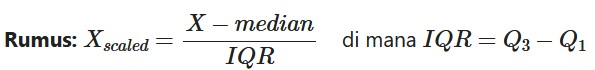

Hasil: sangat robust terhadap outlier ekstrem karena menggunakan median (bukan mean) dan IQR (bukan std).

In [ ]:
# RobustScaler
rs = RobustScaler()
X_rs = rs.fit_transform(df_skala)

print(f'Center (median) per fitur : {rs.center_.round(3)}')
print(f'Scale (IQR) per fitur     : {rs.scale_.round(3)}')
print('\nHasil RobustScaler:')
print(pd.DataFrame(X_rs, columns=['Usia_rb', 'Pend_rb']).round(3))

# **2.4 Visualisasi Perbandingan Tiga Scaler**

In [ ]:
# Visualisasi perbandingan: data asli vs hasil 3 scaler
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Data Asli', 'MinMaxScaler', 'StandardScaler', 'RobustScaler']
data_list = [
    df_skala.values,
    X_mm,
    X_ss,
    X_rs,
]

for ax, title, data in zip(axes, titles, data_list):
    ax.scatter(data[:, 0], data[:, 1], s=120, c='#028090', edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Usia')
    ax.set_ylabel('Pendapatan')
    ax.grid(alpha=0.3)

plt.suptitle('Perbandingan Hasil Tiga Scaler pada Data yang Sama',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Kesimpulan:')
print('- MinMaxScaler  : semua nilai mampat di rentang [0, 1] - cocok untuk Neural Net & image.')
print('- StandardScaler: pusat di (0, 0), skala seragam berdasarkan std - paling umum dipakai.')
print('- RobustScaler  : pusat di median, robust terhadap outlier - bila ada outlier ekstrem.')

# **BAGIAN 3 — Train-Test Split**

Konsep: Membagi dataset menjadi dua bagian:

    Training set → data yang dipakai model untuk belajar
    Test set → data yang belum pernah dilihat model, untuk evaluasi yang jujur

Tanpa pemisahan ini, kita tidak tahu apakah model benar-benar belajar pola atau sekadar menghafal (overfitting).

In [ ]:
# Buat dataset sintetis dengan kelas tidak seimbang (90% kelas 0, 10% kelas 1)
n = 200
X_demo = pd.DataFrame({
    'fitur_1': np.random.randn(n),
    'fitur_2': np.random.randn(n),
})
y_demo = pd.Series([0]*180 + [1]*20)   # 90% : 10%

print(f'Total data    : {n} baris')
print(f'Proporsi y    :')
print(y_demo.value_counts(normalize=True).round(3))

**3.1 Split TANPA stratify — proporsi kelas bisa berubah**

In [ ]:
# Split tanpa stratify
X_tr, X_te, y_tr, y_te = train_test_split(
    X_demo, y_demo,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f'Train: {len(X_tr)} baris   |   Test: {len(X_te)} baris\n')
print('Proporsi kelas di TRAIN:')
print(y_tr.value_counts(normalize=True).round(3))
print('\nProporsi kelas di TEST:')
print(y_te.value_counts(normalize=True).round(3))
print('\nProporsi kelas tidak konsisten antara train dan test - bisa menyesatkan evaluasi.')

### **3.2 Split DENGAN stratify — proporsi kelas terjaga**


In [ ]:
# Split dengan stratify - proporsi kelas terjaga
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_demo, y_demo,
    test_size=0.2,
    random_state=42,
    stratify=y_demo   # ← kunci: jaga proporsi kelas
)

print(f'Train: {len(X_tr_s)} baris   |   Test: {len(X_te_s)} baris\n')
print('Proporsi kelas di TRAIN (stratified):')
print(y_tr_s.value_counts(normalize=True).round(3))
print('\nProporsi kelas di TEST (stratified):')
print(y_te_s.value_counts(normalize=True).round(3))
print('\nProporsi kelas konsisten 90:10 di train dan test - evaluasi lebih adil.')

# **Catatan Penting: Data Leakage**

Urutan yang BENAR untuk mencegah data leakage:

    Split dulu → training set dan test set
    fit scaler hanya pada X_train → belajar parameter dari training set saja
    transform pada X_train DAN X_test (jangan fit_transform di test set!)

Jika scaler di-fit pada keseluruhan data sebelum split, informasi statistik (mean, std, min, max) dari test set akan bocor ke proses pelatihan dan membuat evaluasi terlalu optimis.

## **BAGIAN 4 — HANDS-ON: Pipeline Preprocessing Dataset Titanic**

Bagian utama notebook. Menggabungkan seluruh teknik di atas dalam satu pipeline end-to-end menggunakan dataset Titanic dari Seaborn.

Dataset Titanic dipilih karena memiliki:

    Kombinasi fitur numerik dan kategorikal
    Missing values pada beberapa kolom
    Kelas target yang tidak seimbang (~62% tidak selamat, ~38% selamat)

## **Langkah 1 — Load Dataset & EDA Singkat**

In [ ]:
# Load dataset Titanic dari Seaborn
df = sns.load_dataset('titanic')

# Pilih kolom yang akan digunakan (sesuai modul)
cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']
df = df[cols].copy()

print(f'Shape dataset: {df.shape}')
print(f'\n5 baris pertama:')
df.head()

In [ ]:
# Cek tipe data
print('Tipe data setiap kolom:')
print(df.dtypes)

In [ ]:
# Cek missing values
print('Jumlah missing values per kolom:')
missing = df.isnull().sum()
print(missing[missing > 0])
print(f'\nTotal baris dengan minimal 1 nilai hilang: {df.isnull().any(axis=1).sum()}')

In [ ]:
# Distribusi target (survived) - cek apakah seimbang
print('Distribusi target (survived):')
print(df['survived'].value_counts())
print('\nProporsi:')
print(df['survived'].value_counts(normalize=True).round(3))
print('\nKelas TIDAK seimbang: ~61.6% (tidak selamat) vs ~38.4% (selamat).')
print('Maka kita WAJIB pakai stratify=y saat split.')

## **Langkah 2 — Handling Missing Values**

Strategi:

    age (numerik, 177 NaN) → isi dengan median (robust terhadap outlier dibanding mean)
    embarked (kategorikal, 2 NaN) → isi dengan modus (nilai paling sering muncul)


In [ ]:
# Backup jumlah missing sebelum imputasi
missing_before = df.isnull().sum()

# Age: isi dengan median
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)
print(f'age   diisi dengan median  = {median_age}')

# Embarked: isi dengan modus
mode_embarked = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(mode_embarked)
print(f'embarked diisi dengan modus = {mode_embarked!r}')

# Verifikasi
print('\nMissing values setelah handling:')
print(df.isnull().sum())
print('\nSemua kolom sudah 0 missing - siap masuk ke encoding.')

## **Langkah 3 — Encoding Kategorikal**

Kolom yang masih bertipe string: sex (nominal biner) dan embarked (nominal, 3 kategori: C/Q/S).

Metode yang dipilih: One-Hot Encoding dengan drop_first=True untuk menghindari dummy variable trap.

In [ ]:
# Cek kolom kategorikal sebelum encoding
print('Kolom dengan tipe object/category:')
print(df.select_dtypes(include=['object', 'category']).columns.tolist())
print('\nNilai unik:')
print(f"  sex      : {df['sex'].unique()}")
print(f"  embarked : {df['embarked'].unique()}")

In [ ]:
# One-Hot Encoding untuk sex dan embarked
df = pd.get_dummies(
    df,
    columns=['sex', 'embarked'],
    drop_first=True,   # hindari dummy variable trap
    dtype=int          # hasilkan 0/1 (bukan True/False)
)

print('Kolom setelah encoding:')
print(df.columns.tolist())
print(f'\nShape: {df.shape}')
df.head()

### **Langkah 4 — Train-Test Split**

Bagi data 80:20 dengan stratify=y untuk menjaga proporsi kelas survived (~62:38) baik di training set maupun test set.

In [ ]:
# Pisahkan fitur (X) dan target (y)
X = df.drop('survived', axis=1)
y = df['survived']

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'\nKolom fitur X: {X.columns.tolist()}')

In [ ]:
# Train-Test Split 80:20 dengan stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y           # ← proporsi kelas terjaga
)

print(f'X_train: {X_train.shape}   |   y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}   |   y_test : {y_test.shape}')

print('\nProporsi survived di TRAIN:')
print(y_train.value_counts(normalize=True).round(3))
print('\nProporsi survived di TEST:')
print(y_test.value_counts(normalize=True).round(3))
print('\nProporsi konsisten ~61.6 : 38.4 - berhasil dijaga oleh stratify.')

### **Langkah 5 — Feature Scaling**

Strategi:

    Pakai StandardScaler (pilihan default paling aman untuk sebagian besar algoritma ML)
    Hanya scale kolom numerik kontinu — kolom biner hasil OHE (sex_male, embarked_Q, embarked_S) TIDAK perlu di-scale
    fit_transform pada X_train saja → transform pada X_test (mencegah data leakage)


In [ ]:
# Kolom numerik yang perlu di-scale (kolom biner OHE TIDAK perlu)
num_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']
print(f'Kolom yang akan di-scale: {num_cols}')

# Cek skala sebelum scaling
print('\nStatistik X_train SEBELUM scaling:')
print(X_train[num_cols].describe().round(2))

In [ ]:
# Inisialisasi StandardScaler
scaler = StandardScaler()

# fit_transform pada X_train (belajar mean & std dari sini)
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# transform saja pada X_test (gunakan mean & std dari training!)
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f'Mean scaler (dari X_train) : {scaler.mean_.round(3)}')
print(f'Std  scaler (dari X_train) : {scaler.scale_.round(3)}')

In [ ]:
# Verifikasi: statistik X_train SETELAH scaling (mean ~ 0, std ~ 1)
print('Statistik X_train SETELAH scaling:')
print(X_train[num_cols].describe().round(3))

In [ ]:
# Statistik X_test SETELAH scaling
# Mean tidak harus tepat 0 (karena pakai mean dari train, bukan test)
print('Statistik X_test SETELAH scaling:')
print(X_test[num_cols].describe().round(3))
print('\nCatatan: mean X_test tidak persis 0 karena scaler di-fit pada X_train,')
print('lalu hanya di-transform pada X_test. Ini perilaku yang BENAR.')

### **Verifikasi Akhir — Data Siap Dilatih**

In [ ]:
# Tampilan akhir X_train
print('Contoh X_train setelah seluruh preprocessing:')
X_train.head()

In [ ]:
# Ringkasan akhir
print('=' * 60)
print('   RINGKASAN PIPELINE PREPROCESSING TITANIC')
print('=' * 60)
print(f'Total fitur (X)         : {X_train.shape[1]} kolom')
print(f'  - Kolom numerik (scaled) : {num_cols}')
print(f'  - Kolom biner (OHE)      : {[c for c in X_train.columns if c not in num_cols]}')
print()
print(f'X_train : {X_train.shape}')
print(f'y_train : {y_train.shape}  | proporsi: {dict(y_train.value_counts(normalize=True).round(3))}')
print(f'X_test  : {X_test.shape}')
print(f'y_test  : {y_test.shape}  | proporsi: {dict(y_test.value_counts(normalize=True).round(3))}')
print()
print('Missing values di X_train :', X_train.isnull().sum().sum())
print('Missing values di X_test  :', X_test.isnull().sum().sum())
print()
print('DATA SUDAH SIAP DILATIH MODEL MACHINE LEARNING!')

### **Bonus — Visualisasi Distribusi Sebelum vs Sesudah Scaling**

Untuk membuktikan bahwa StandardScaler benar-benar membawa semua fitur ke skala yang sebanding (mean=0, std=1) tanpa mengubah bentuk distribusi.

In [ ]:
# Reload data asli untuk perbandingan visual
df_compare = sns.load_dataset('titanic')[cols].copy()
df_compare['age'] = df_compare['age'].fillna(df_compare['age'].median())
df_compare['embarked'] = df_compare['embarked'].fillna(df_compare['embarked'].mode()[0])

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# Baris atas: distribusi SEBELUM scaling
for ax, col in zip(axes[0], num_cols):
    sns.histplot(df_compare[col], bins=25, ax=ax, color='#E69B3A', kde=True)
    ax.set_title(f'{col} (SEBELUM)', fontweight='bold')
    ax.set_xlabel('')

# Baris bawah: distribusi SETELAH scaling (X_train)
for ax, col in zip(axes[1], num_cols):
    sns.histplot(X_train[col], bins=25, ax=ax, color='#028090', kde=True)
    ax.set_title(f'{col} (SETELAH StandardScaler)', fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Distribusi Fitur Numerik: Sebelum vs Setelah StandardScaler',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print('Bentuk distribusi tetap sama, hanya skala (sumbu X) yang berubah ke pusat 0.')

## **Refleksi Singkat**

Melalui aktivitas hands-on Pertemuan 6 ini, saya berhasil:

    1. **Memahami filosof**i *Garbage In, Garbage Out* — model ML sehebat apa pun akan gagal jika diberi data yang tidak disiapkan dengan benar.
    2. **Menerapkan tiga metode encoding** — Label Encoding untuk target/biner, One-Hot Encoding untuk fitur nominal, dan Ordinal Encoding untuk fitur dengan urutan alami (seperti tingkat pendidikan).
    3. **Membandingkan tiga scaler**  — MinMaxScaler (rentang tetap 0–1, cocok Neural Net), StandardScaler (default paling aman untuk sebagian besar kasus), dan RobustScaler (robust terhadap outlier ekstrem).
    4. **Memahami pentingnya stratify=y** — pada dataset Titanic yang tidak seimbang (62:38), stratifikasi menjaga proporsi kelas konsisten antara training dan test set sehingga evaluasi model menjadi adil.
    5. Mencegah *data leakage*** dengan urutan yang benar **teks tebal**: **Split dulu → fit_transform pada X_train saja → transform saja pada X_test. Jika scaler di-fit pada keseluruhan data, statistik test set akan bocor ke training dan evaluasi menjadi terlalu optimis.
    6. **Membangun pipeline preprocessing end-to-end pada dataset Titanic**: load → handle missing → encode → split (stratify) → scale (fit di train, transform di test). Data akhir sudah siap untuk dilatih model klasifikasi seperti Logistic Regression atau Random Forest pada pertemuan berikutnya.

 Di modul 6 ini **Persiapan data** (data preprocessing) sangat penting dalam machine learning karena algoritma tidak dapat memproses data mentah secara langsung. Langkah ini berfungsi membersihkan noise, mengisi nilai yang hilang, dan mengubah format agar model dapat mengenali pola secara akurat. Aturan umumnya dikenal sebagai garbage in, garbage out; data yang buruk akan menghasilkan prediksi yang buruk.